# 04 · Reto final

**Individual · 40 minutos repartidos a lo largo de la sesión**

Este notebook **no se hace al final**. Se hace por partes, y cada parte va
justo después del bloque del curso que te da las herramientas:

| | Cuándo | Qué | Tiempo |
|---|---|---|---|
| 📍 **Paso 1** | después del bloque 01 | Cargar y limpiar | 5 min |
| 📍 **Paso 2** | después del bloque 02 | Calcular la desviación | 5 min |
| 📍 **Paso 3** | después del bloque 03 | Graficar y encontrar el hallazgo | 10 min |
| 🏁 **Entrega** | al cierre | Conclusión + exportar + código | 20 min |

---

## 📧 La nueva petición

> **De:** Dirección de Finanzas
> **Para:** Analista de Control Presupuestal
> **Asunto:** Cuautitlán — revisión anual
>
> *"Me reportaron que Cuautitlán viene bien de presupuesto, pero el director
> de planta dice lo contrario. Necesito saber quién tiene razón. Si hay una
> desviación, dime **en qué mes empezó** y si **sigue abierta** o ya se
> corrigió."*

---

### 🔍 Fíjate en lo que cambia

No es el mismo ejercicio con otros números:

```
   EN EL CURSO              EN EL RETO
   ─────────────────        ─────────────────────────────
   Hermosillo               Cuautitlán
   Q2 2026 (3 meses)        los 18 meses
   ¿QUÉ CENTRO de costo?    ¿EN QUÉ MES empezó?
                            ¿sigue abierta?
```

La última línea es la importante: **cambia el eje del análisis**. Copiar tu
agrupación del bloque 2 tal cual no responde esta pregunta.

Y hay una discrepancia que resolver: el reporte dice una cosa y el director
de planta dice otra. Alguien está mirando datos distintos.

---
---

# 📍 PASO 1 · Cargar y limpiar

> **Hazlo después del bloque 01.** Tienes 5 minutos.

Los datos están en `datos/reto/`, con la misma estructura de tres tablas.

> 💡 **Pista:** están los mismos cinco problemas que ya resolviste, y se
> arreglan con las mismas técnicas. **Pero no necesariamente están en las
> mismas tablas.** Revisa las tres antes de decidir qué limpiar.
>
> Concretamente: cuenta las filas de cada tabla y compáralas con las que
> deberían tener. Una de ellas te va a sorprender.

In [ ]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from utils.verificar import verificar, resumen_reto

RETO = RAIZ / "datos" / "reto"
SALIDAS = RAIZ / "salidas"
SALIDAS.mkdir(exist_ok=True)

ROJO, VERDE, GRIS = "#C0392B", "#27AE60", "#7F8C8D"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

# Un primer diagnóstico: ¿cuántas filas trae cada tabla?
for nombre in ["hechos_gasto", "presupuesto", "dim_centro_costo"]:
    ruta = RETO / f"{nombre}.csv"
    try:
        n = len(pd.read_csv(ruta))
        print(f"  {nombre:<20} {n:>7,} filas")
    except UnicodeDecodeError:
        print(f"  {nombre:<20}  ⚠️  no abre con utf-8")

  hechos_gasto          12,000 filas
  presupuesto              601 filas
  dim_centro_costo      ⚠️  no abre con utf-8


Deberían ser 12,000 hechos y **576** filas de presupuesto
(4 plantas × 8 centros × 18 meses). Compara con lo que salió.

Ahora limpia las tres tablas. Reutiliza tu código del bloque 01.

In [ ]:
# ── Cargar ──────────────────────────────────────────────────────────────
hechos = pd.read_csv(RETO / "hechos_gasto.csv")
presupuesto = pd.read_csv(RETO / "presupuesto.csv")
dim_cc = pd.read_csv(RETO / "dim_centro_costo.csv", encoding="__________")

# ── ② Importes a número ─────────────────────────────────────────────────
def a_numero(serie):
    return (serie.str.replace("___", "", regex=False)
                 .str.replace("___", "___", regex=False)
                 .astype(float))

hechos["monto"] = a_numero(hechos["monto"])
presupuesto["monto_presupuesto"] = a_numero(presupuesto["monto_presupuesto"])

# ── ③ Duplicados ── ¿en qué tabla están esta vez? ───────────────────────
# Quita el comentario de la línea que corresponda, o escribe la tuya.
# hechos = hechos.drop_duplicates(subset=["folio"])
# presupuesto = presupuesto.drop_duplicates(subset=[____________________])

# ── ④ Llaves de texto ───────────────────────────────────────────────────
for tabla in (hechos, presupuesto, dim_cc):
    tabla["centro_costo"] = tabla["centro_costo"].str.______().str.______()

# ── ⑤ Los negativos NO se borran ────────────────────────────────────────

print(f"hechos       {len(hechos):>7,} filas")
print(f"presupuesto  {len(presupuesto):>7,} filas")

In [ ]:
verificar("R1", presupuesto)

> ✅ Cuando el paso 1 te dé correcto, **vuelve al bloque 02 del curso**.

---
---

# 📍 PASO 2 · Calcular la desviación

> **Hazlo después del bloque 02.** Tienes 5 minutos.

Tu consulta del ejercicio 2.7 sirve casi tal cual.

> 💡 **Pista:** cambia la planta — y confirma que estás partiendo de las
> tablas **limpias** del paso 1. Si la desviación te sale negativa, revisa el
> paso 1 antes de seguir.

In [ ]:
hechos["anio"] = hechos["fecha"].str[:4].astype(int)
hechos["mes"] = hechos["fecha"].str[5:7].astype(int)

variance_reto = duckdb.sql("""
    WITH real AS (
        SELECT planta, centro_costo, anio, mes, SUM(monto) AS gasto_real
        FROM hechos GROUP BY planta, centro_costo, anio, mes
    ),
    ppto AS (
        SELECT planta, centro_costo, anio, mes,
               SUM(monto_presupuesto) AS presupuesto
        FROM presupuesto GROUP BY planta, centro_costo, anio, mes
    )
    SELECT r.planta, r.centro_costo, r.anio, r.mes,
           r.gasto_real, p.presupuesto,
           r.gasto_real - p.presupuesto AS variance
    FROM real r
    JOIN ppto p
      ON  r.planta = p.planta AND r.centro_costo = p.centro_costo
      AND r.anio = p.anio     AND r.mes = p.mes
    WHERE r.planta = '____________'
    ORDER BY r.centro_costo, r.anio, r.mes
""").df()

print(f"{len(variance_reto)} filas")
print(f"Desviación total: ${variance_reto['variance'].sum():,.2f}")

In [ ]:
verificar("R2", variance_reto)

> ✅ Cuando te dé correcto: **☕ break**, y luego el bloque 03 del curso.

---
---

# 📍 PASO 3 · Graficar y encontrar el hallazgo

> **Hazlo después del bloque 03.** Tienes 10 minutos.

Ahora sí, la pregunta del directivo: **¿en qué mes empezó y sigue abierta?**

> 💡 **Pista:** antes de graficar, decide la agregación. La pregunta es
> **cuándo** empezó, no **quién** lo causó. ¿Eso cambia por qué columna
> agrupas?

In [ ]:
serie_reto = duckdb.sql("""
    SELECT anio, mes,
           ROUND(SUM(gasto_real), 2)  AS gasto_real,
           ROUND(SUM(presupuesto), 2) AS presupuesto,
           ROUND(SUM(variance), 2)    AS variance
    FROM variance_reto
    GROUP BY ____, ___
    ORDER BY anio, mes
""").df()

serie_reto["periodo"] = (serie_reto["anio"].astype(str) + "-"
                         + serie_reto["mes"].astype(str).str.zfill(2))
serie_reto[["periodo", "gasto_real", "presupuesto", "variance"]]

In [ ]:
verificar("R3", serie_reto)

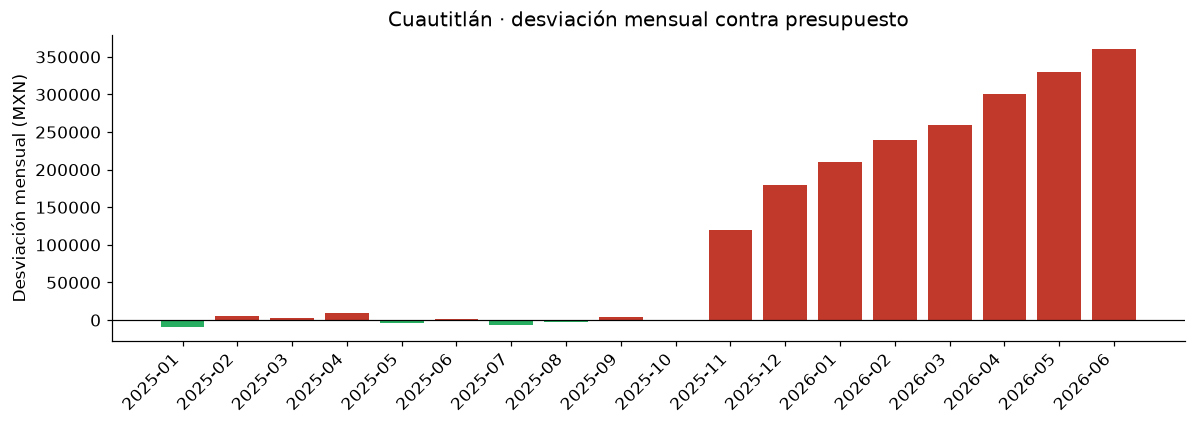

In [ ]:
# Tu gráfico. El andamio está escrito; ponle el título con tu hallazgo.
fig, ax = plt.subplots(figsize=(11, 4))
colores = [ROJO if v > 0 else VERDE for v in serie_reto["variance"]]
ax.bar(serie_reto["periodo"], serie_reto["variance"], color=colores)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(serie_reto)))
ax.set_xticklabels(serie_reto["periodo"], rotation=45, ha="right")
ax.set_ylabel("Desviación mensual (MXN)")
ax.set_title("Cuautitlán · desviación mensual contra presupuesto")
plt.tight_layout()
plt.show()

---
---

# 🏁 ENTREGA · Tu conclusión

> **Al cierre del curso.** Tienes 20 minutos.

## ✍️ Responde al directivo

Escribe aquí lo que le mandarías. Cuatro puntos, en lenguaje de negocio — no
de Python:

1. **¿Quién tenía razón**, el reporte o el director de planta? ¿Por qué los
   dos veían cifras distintas?

2. **¿En qué mes empezó** la desviación? ¿Cómo lo sabes?

3. **¿Sigue abierta o ya se corrigió?** ¿Qué te lo dice?

4. **¿Cuánto es** la desviación acumulada, y qué recomiendas hacer?

> *Escribe aquí tu respuesta…*

---

### Una pregunta más, de método

5. En el caso de Hermosillo, limpiar los datos hizo el problema **más
   pequeño**. Aquí pasó lo contrario. Explica en una frase por qué, y qué te
   dice eso sobre revisar los datos antes de reportar.

> *Escribe aquí tu respuesta…*

---
## Exporta tu reporte

Igual que en el bloque 3: codificación pensada para quien lo va a abrir.

In [ ]:
reporte_reto = duckdb.sql("""
    SELECT planta, centro_costo, anio, mes,
           gasto_real, presupuesto, variance
    FROM variance_reto
    ORDER BY anio, mes, centro_costo
""").df()

reporte_reto.to_csv(
    SALIDAS / "reto_reporte.csv",
    index=False,
    encoding="___________",
)

print(f"{len(reporte_reto)} filas → salidas/reto_reporte.csv")

In [ ]:
verificar("R4", reporte_reto)

---
## Tu marcador

Ejecuta esta celda. Te da un **código de entrega** derivado de tus
resultados: mándalo junto con `salidas/reto_reporte.csv`.

In [ ]:
codigo = resumen_reto()

---

# 🎓 Terminaste

Recorriste dos veces el flujo completo, con dos datasets y dos conclusiones
opuestas:

```
   HERMOSILLO                        CUAUTITLÁN
   duplicados en HECHOS              duplicados en PRESUPUESTO
   parecía $4.0M de sobregasto       parecía $0.5M de ahorro
            ↓ limpiar                         ↓ limpiar
   eran $1.0M — se ENCOGE            eran $2.0M — APARECE
   casi reportas un falso positivo   casi te pierdes uno real
```

**La misma técnica. Tabla distinta. Conclusión opuesta.**

Lo que llevas no es `drop_duplicates`. Es el hábito de preguntarte, antes de
enviar un número a un comité: *¿de dónde salió este dato, y qué le pasó en el
camino?*

---

### Para tu trabajo el lunes

| Cuando… | Acuérdate de… |
|---|---|
| un archivo no abre | la tabla de codificaciones |
| una columna no suma | mira `.info()` antes de confiar |
| un join cambia el número de filas | cuenta antes y después, siempre |
| un total se ve raro | busca duplicados de carga |
| un valor sale negativo | pregunta antes de borrar |
| exportas para Power BI | `encoding="utf-8-sig"` |